In [1]:
import geopandas as gpd
import rasterio
import pandas as pd
import numpy as np

## Masking North Part

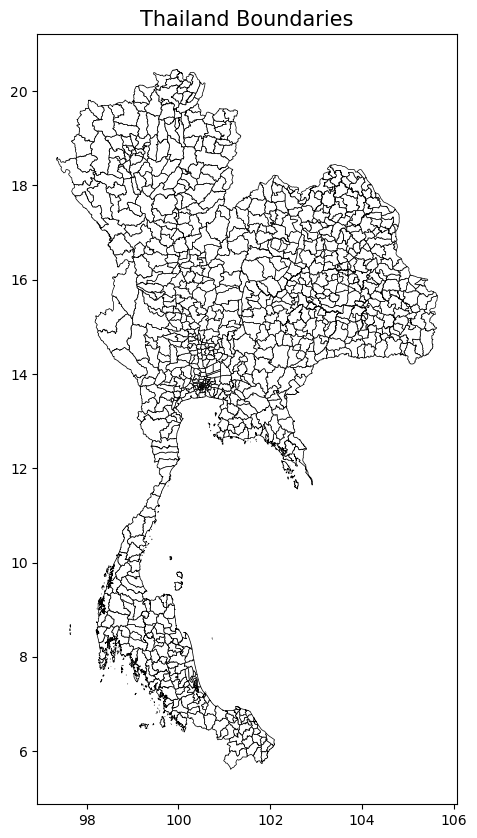

In [ ]:
thai_gdf = gpd.read_file("../../gadm41_THA_shp/gadm41_THA_2.shp")
fig, ax = plt.subplots(figsize=(10, 10))
thai_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

ax.set_title("Thailand Boundaries", fontsize=15)
plt.show()

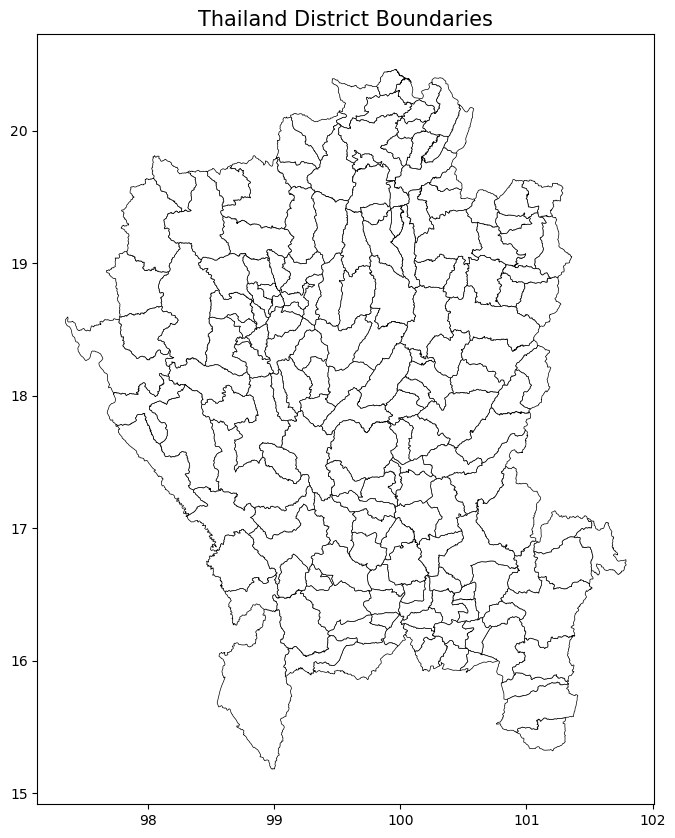

In [ ]:
gdf = gpd.read_file("../../gadm41_THA_shp/gadm41_THA_2.shp")
# gdf.info()

north_provinces = [
    "Chiang Mai","Chiang Rai","Lampang","Lamphun","Mae Hong Son",
    "Nan","Phayao","Phrae","Uttaradit","Tak","Sukhothai",
    "Phitsanulok","Kamphaeng Phet","Phichit","Phetchabun"
]

north = gdf[gdf["NAME_1"].isin(north_provinces)]

# north.info()
fig, ax = plt.subplots(figsize=(10, 10))
north.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

ax.set_title("Thailand District Boundaries", fontsize=15)
plt.show()
north.to_file("north_aumphur_thailand.shp")

-----------------------------------------------------------------------------------------------------------------------------------------------------------

# Load shapefiles

In [3]:
import geopandas as gpd
import pandas as pd

years = [2023, 2024, 2025]

fire_all = []

for y in years:
    df = gpd.read_file(f"../../data/MODIS_{y}.shp")
    df["ACQ_DATE"] = pd.to_datetime(df["ACQ_DATE"])
    df["fire"] = 1
    fire_all.append(df)

fire_df = pd.concat(fire_all, ignore_index=True)

In [4]:
fire_all[0].info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 29173 entries, 0 to 29172
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   LATITUDE    29173 non-null  float64       
 1   LONGITUDE   29173 non-null  float64       
 2   BRIGHTNESS  29173 non-null  float64       
 3   SCAN        29173 non-null  float64       
 4   TRACK       29173 non-null  float64       
 5   ACQ_DATE    29173 non-null  datetime64[ms]
 6   ACQ_TIME    29173 non-null  object        
 7   SATELLITE   29173 non-null  object        
 8   INSTRUMENT  29173 non-null  object        
 9   CONFIDENCE  29173 non-null  int32         
 10  VERSION     29173 non-null  object        
 11  BRIGHT_T31  29173 non-null  float64       
 12  FRP         29173 non-null  float64       
 13  DAYNIGHT    29173 non-null  object        
 14  TYPE        29173 non-null  int64         
 15  geometry    29173 non-null  geometry      
 16  fire        29

In [5]:
fire_all[0].head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,fire
0,6.2859,101.2527,314.1,1.3,1.1,2023-01-01,0642,Aqua,MODIS,66,61.03,296.5,11.1,D,0,POINT (101.2527 6.2859),1
1,6.2841,101.2413,317.3,1.3,1.1,2023-01-01,0642,Aqua,MODIS,71,61.03,296.0,15.4,D,0,POINT (101.2413 6.2841),1
2,9.1707,99.8283,310.2,1.4,1.2,2023-01-01,0642,Aqua,MODIS,51,61.03,293.6,10.9,D,0,POINT (99.8283 9.1707),1
3,12.0924,102.7745,306.8,1.0,1.0,2023-01-01,0643,Aqua,MODIS,19,61.03,291.1,4.1,D,0,POINT (102.7745 12.0924),1
4,12.8855,101.0871,314.5,1.1,1.0,2023-01-01,0643,Aqua,MODIS,36,61.03,300.9,4.0,D,0,POINT (101.0871 12.8855),1


In [6]:
fire_all[0][fire_all[0]["fire"] == 0].head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,fire


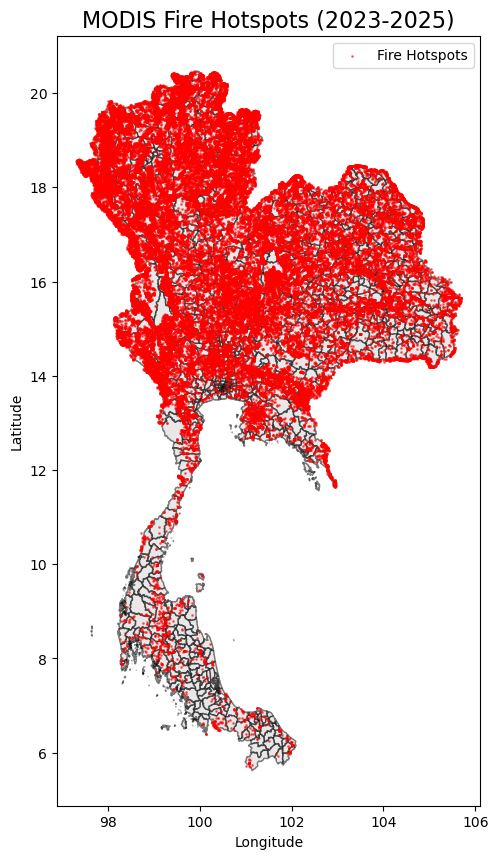

In [7]:
# Import matplotlib for data visualization and plotting.
import matplotlib.pyplot as plt

# 1. Create a Figure and Axes to define the image size
# Load the shapefile of Thailand's map boundaries into a GeoDataFrame.
gdf_thailand = gpd.read_file("../../gadm41_THA_shp/gadm41_THA_2.shp")
# Initialize a plot figure and axes with a specific size of 10x10 inches.
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot the GeoDataFrame 
# Plot the base map of Thailand using a light grey fill and black borders.
gdf_thailand.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

# Set color to red, reduce point size (markersize), and adjust transparency (alpha) to see overlapping points
# Overlay the fire hotspot coordinate data onto the base map.
fire_df.plot(ax=ax, color='red', markersize=1, alpha=0.5, label='Fire Hotspots')

# 3. Add further plot decorations
# Set the title and labels for the X and Y axes, and display the legend for clarity.
ax.set_title("MODIS Fire Hotspots (2023-2025)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

# 4. Display the plot
# Render and show the final map visualization.
plt.show()

# Check rasters

In [8]:
# Import necessary libraries for geospatial raster processing, data manipulation, array operations, and plotting.
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Raster data to check its bounds (extent)
# Define the file path and open the GeoTIFF image to extract its spatial bounding box.
raster_path = "../../data/GEE_FIRE/fire_feature_2023_01.tif"
with rasterio.open(raster_path) as src:
    raster_bounds = src.bounds
    print(f"Raster Bounds: {raster_bounds}")

# 2. Filter the GeoDataFrame (fire_df) to keep only points within the Raster bounds
# Based on the BoundingBox: left=97.34, bottom=15.17, right=101.79, top=20.46
# Use boolean indexing to create a new DataFrame containing only the hotspots that fall geographically inside the raster's area.
fire_df_filtered = fire_df[
    (fire_df['LONGITUDE'] >= raster_bounds.left) & 
    (fire_df['LONGITUDE'] <= raster_bounds.right) &
    (fire_df['LATITUDE'] >= raster_bounds.bottom) & 
    (fire_df['LATITUDE'] <= raster_bounds.top)
].copy()

# Output the row counts to verify the data reduction after the spatial filtering process.
print(f"Number of records before filtering: {len(fire_df)}")
print(f"Number of records after filtering by spatial bounds: {len(fire_df_filtered)}")

Raster Bounds: BoundingBox(left=97.34413913304371, bottom=15.177935040483437, right=101.79079978943534, top=20.46541880281094)
Number of records before filtering: 67932
Number of records after filtering by spatial bounds: 40180


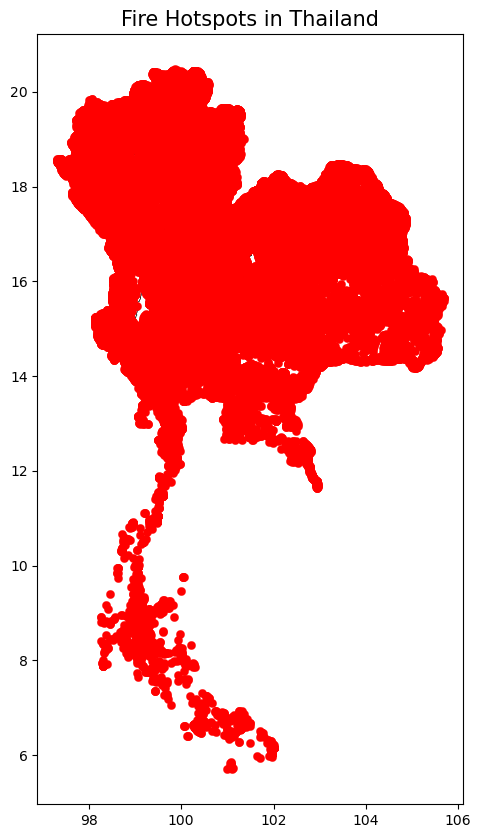

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))
north.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
fire_df.plot(ax=ax, color='red', linewidth=0.2)

ax.set_title("Fire Hotspots in Thailand", fontsize=15)
plt.show()

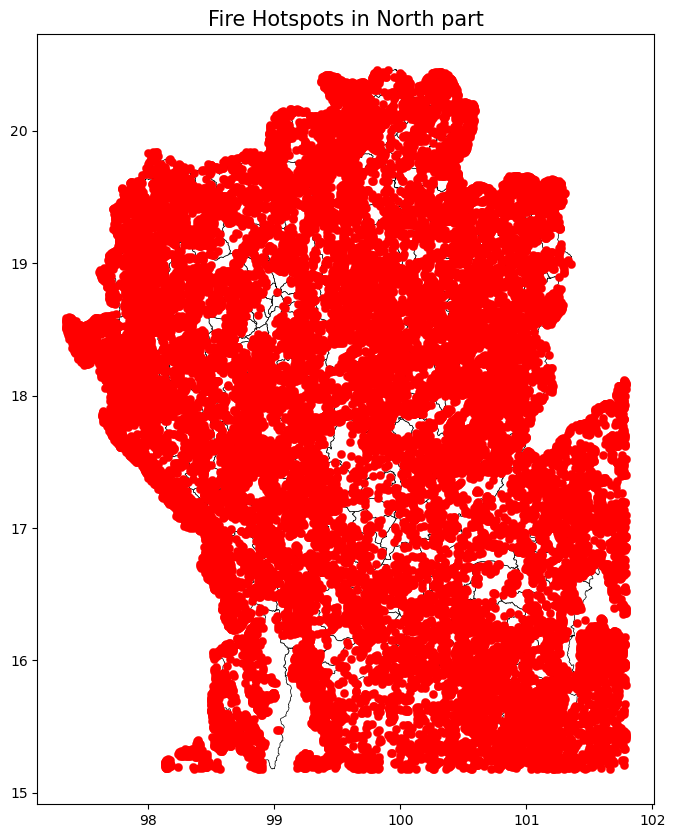

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))
north.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
fire_df_filtered.plot(ax=ax, color='red', linewidth=0.2)

ax.set_title("Fire Hotspots in North part", fontsize=15)
plt.show()

In [9]:
# Define the list of feature names corresponding to the bands/layers in the raster file.
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

def sample_raster_precise(df, raster_path):
    # Open the raster file in read mode.
    with rasterio.open(raster_path) as src:
        # Extract coordinates only for the filtered points
        # Create a list of (longitude, latitude) tuples to be used for sampling.
        coords = [(x, y) for x, y in zip(df.LONGITUDE, df.LATITUDE)]
        
        # Extract values from Raster
        # Use rasterio's 'sample' function to extract pixel values at the exact coordinates.
        # Convert the resulting generator to a list, then to a numpy array for efficient indexing.
        samples = np.array(list(src.sample(coords)))

    # Store values into DataFrame
    # Loop through the feature names and assign the corresponding column from the samples array to the DataFrame.
    for i, name in enumerate(feature_names):
        df[name] = samples[:, i]
    
    return df

# Run the extraction process
# Apply the function to our spatially filtered DataFrame to extract all environmental features.
fire_df_sampled = sample_raster_precise(fire_df_filtered, raster_path)

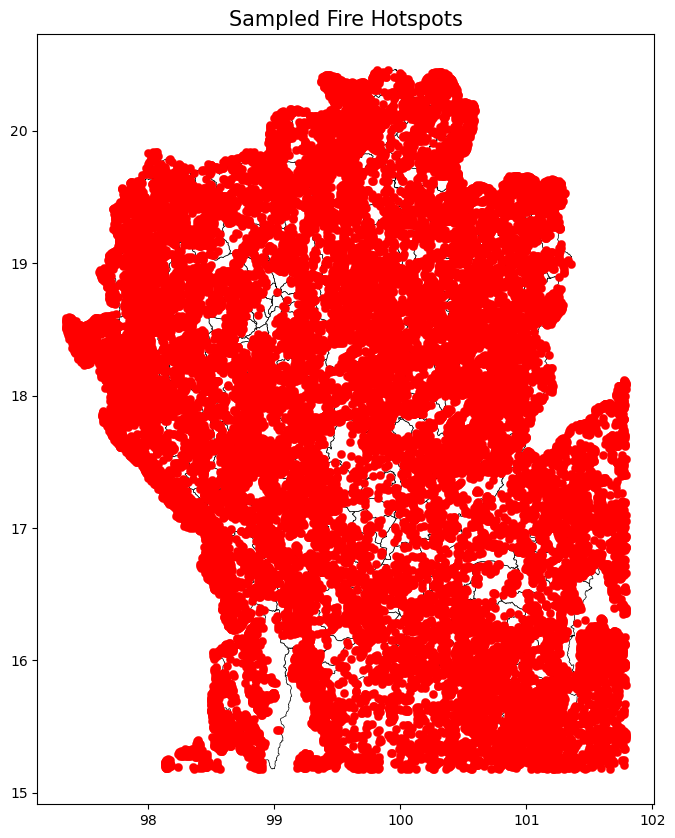

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))
north.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
fire_df_sampled.plot(ax=ax, color='red', linewidth=0.2)

ax.set_title("Sampled Fire Hotspots", fontsize=15)
plt.show()

In [10]:
# 1. Check how many NaNs are in each column
print("Number of NaN values in each feature:")
# Calculate and print the total number of missing values (NaN) for each specified feature column.
print(fire_df_sampled[feature_names].isna().sum())

# 2. Drop rows with NaN values (due to the lack of cloud-free pixel data for that month)
# Remove any rows that contain missing values in the feature columns to ensure data quality for the model.
df_final = fire_df_sampled.dropna(subset=feature_names)

print(f"Number of actually usable records (no NaN): {len(df_final)}")

# 3. View the statistical summary of the extracted data
# Check if the filtered DataFrame still contains data, then generate descriptive statistics (mean, min, max, etc.).
if len(df_final) > 0:
    print("\nStatistical summary of the actually extracted data:")
    print(df_final[feature_names].describe())
else:
    # Print a warning if all rows were dropped, which can happen if the satellite imagery was completely obscured by clouds.
    print("\nWarning: No complete data left for this month (possibly due to cloud cover over the entire area)")

Number of NaN values in each feature:
ndvi             9535
ndwi             9535
nbr              9535
blue             9535
green            9535
red              9535
nir              9535
swir1            9535
swir2            9535
temp             9535
soil_moisture    9535
wind_u           9535
wind_v           9535
elev             9535
slope            9535
aspect           9535
landcover        9535
dtype: int64
Number of actually usable records (no NaN): 30645

Statistical summary of the actually extracted data:
               ndvi          ndwi           nbr          blue         green  \
count  30645.000000  30645.000000  30645.000000  30645.000000  30645.000000   
mean       0.392177     -0.378506      0.247786   1385.714355   1576.775024   
std        0.096743      0.068098      0.120057    162.290192    184.006577   
min       -0.126253     -0.553033     -0.277428   1109.000000   1247.500000   
25%        0.332692     -0.425029      0.175137   1277.000000   1453.000000  

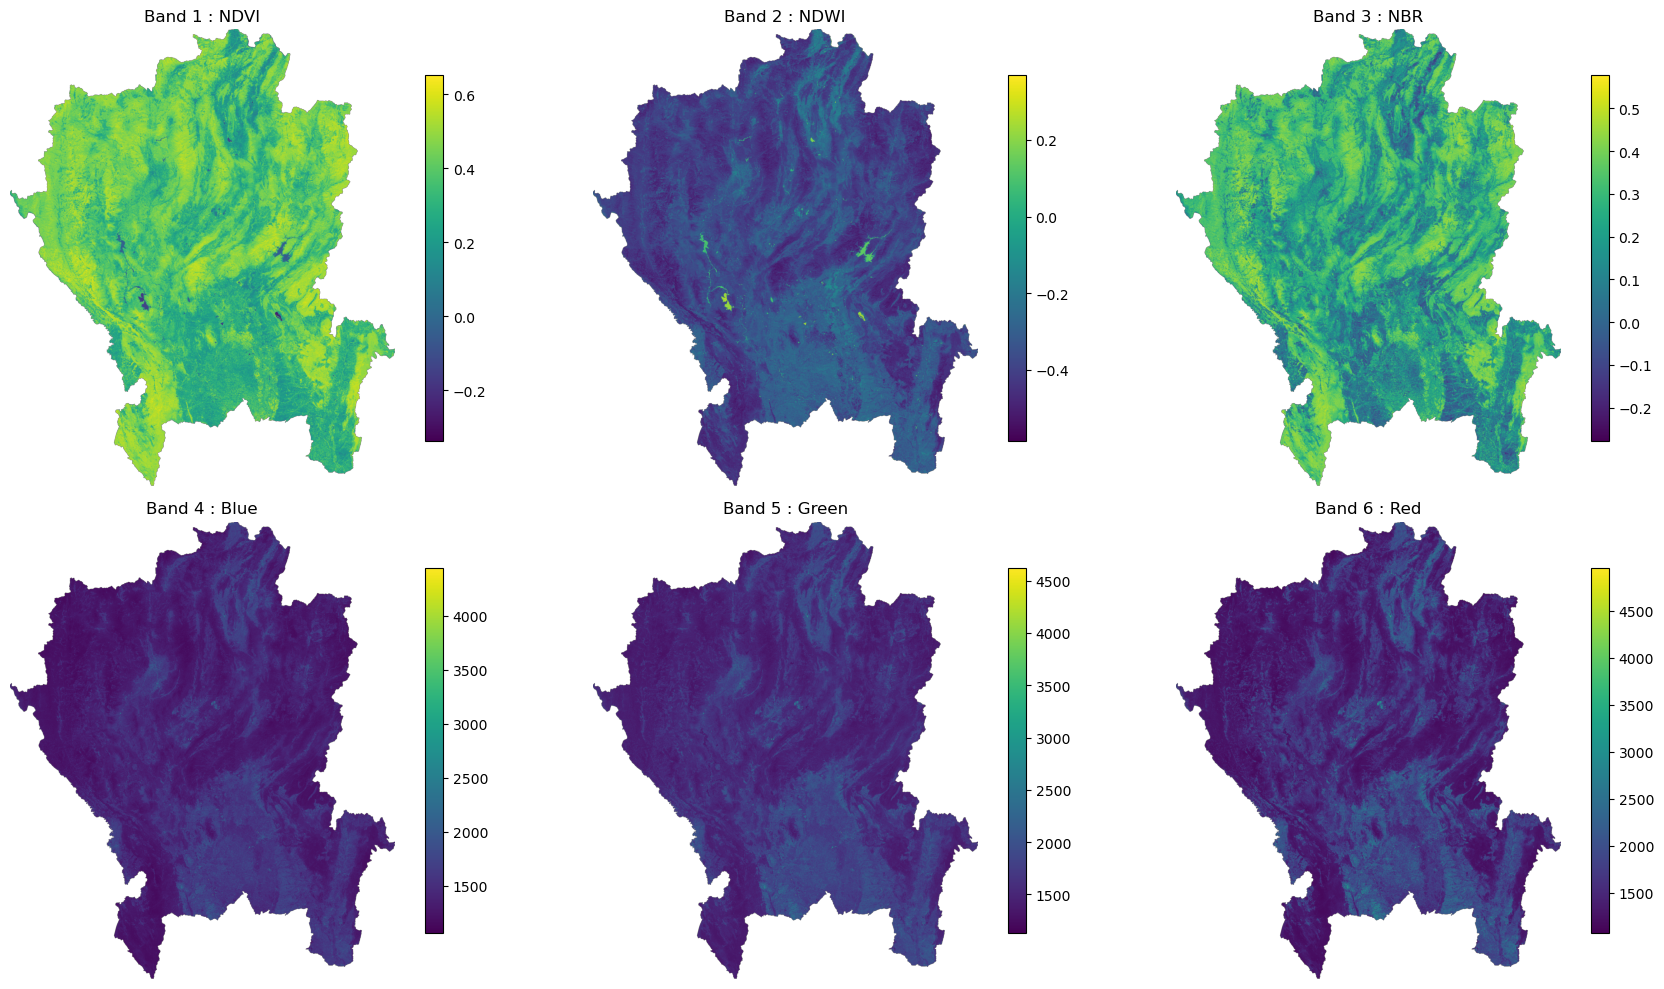

In [11]:
# Import necessary libraries (assuming matplotlib and rasterio are imported earlier)
# import rasterio
# import matplotlib.pyplot as plt

# 1. Specify the path of the Raster file to view
# Define the file location of the multi-band satellite image (GeoTIFF) to be visualized.
raster_path = "../../data/GEE_FIRE/fire_feature_2023_01.tif"

# Names of the different bands (based on your list)
# Create a list mapping the first 6 indices to their respective environmental indices and spectral bands.
band_names = ['NDVI', 'NDWI', 'NBR', 'Blue', 'Green', 'Red']

# 2. Create a Figure and divide the area into a grid (e.g., 2 rows and 3 columns)
# Initialize a matplotlib figure and a grid of subplots to display all 6 bands together.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# Flatten the 2D axes array into a 1D array to allow easy sequential iteration.
axes = axes.flatten() 

# Open the raster dataset using a context manager to ensure proper file closing.
with rasterio.open(raster_path) as src:
    # 3. Loop through and read each band (rasterio starts counting from 1)
    for i in range(6): 
        # Extract the 2D pixel array for the current band.
        band_data = src.read(i + 1) # Read bands 1 to 6
        
        # 4. Plot onto the subplot
        # Display the array data as an image. 
        # Use 'viridis' colormap as a standard, but it can be changed.
        im = axes[i].imshow(band_data, cmap='viridis') 
        
        # Set title and add a colorbar
        axes[i].set_title(f"Band {i+1} : {band_names[i]}")
        # Attach a color scale reference to the specific subplot.
        fig.colorbar(im, ax=axes[i], shrink=0.8) # Shrink to prevent the colorbar from being too long
        
        # Turn off axes for a cleaner look (or leave them on if you want to see coordinates)
        # Hide the X and Y ticks to focus purely on the visual data.
        axes[i].axis('off')

# Automatically adjust subplot parameters to give specified padding and prevent overlap.
plt.tight_layout() # Adjust spacing
# Render and display the final compiled figure.
plt.show()

# Merge Rasters

In [12]:
# Import necessary libraries for geospatial processing, data manipulation, array operations, and file pattern matching.
import rasterio
import pandas as pd
import numpy as np
import glob

# Find and sort all GeoTIFF files matching the specific naming pattern in the directory.
raster_files = sorted(glob.glob("../../data/GEE_FIRE/fire_feature_*.tif"))

all_fire_data = []
# Define the list of environmental features we expect to extract from the raster bands.
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

# Loop through each raster file found in the directory.
for raster_path in raster_files:
    # 1. Load the boundaries of the current Raster
    # Open the current raster to access its metadata and spatial extent.
    with rasterio.open(raster_path) as src:
        raster_bounds = src.bounds
        # print(f"Processing: {raster_path}") # Uncomment to track processing progress
        
        # 2. Extract year and month from the filename (assuming filename format is ...fire_feature_2023_01.tif)
        # Parse the file path string to dynamically identify the year and month for temporal matching.
        name = raster_path.split("/")[-1]
        parts = name.replace(".tif","").split("_")
        year = int(parts[3])
        month = int(parts[4])

        # 3. Filter point data (fire_df) specifically for the matching year/month AND ensuring they "must be within the spatial bounds" of this Raster
        # Create a spatial and temporal subset of the main fire DataFrame that aligns perfectly with the current raster image.
        subset = fire_df[
            (fire_df["ACQ_DATE"].dt.year == year) &
            (fire_df["ACQ_DATE"].dt.month == month) &
            (fire_df['LONGITUDE'] >= raster_bounds.left) & 
            (fire_df['LONGITUDE'] <= raster_bounds.right) &
            (fire_df['LATITUDE'] >= raster_bounds.bottom) & 
            (fire_df['LATITUDE'] <= raster_bounds.top)
        ].copy()

        # If no fire hotspots fall within this raster's time and area, skip to the next file.
        if len(subset) == 0:
            continue

        # 4. Extract values (Sampling) from the Raster
        # Generate a list of coordinate tuples and extract the corresponding pixel values across all bands.
        coords = [(x, y) for x, y in zip(subset.LONGITUDE, subset.LATITUDE)]
        samples = np.array(list(src.sample(coords)))

        # 5. Store values into columns
        # Iteratively assign the extracted array data to new feature columns in our subset DataFrame.
        for i, name_feat in enumerate(feature_names):
            subset[name_feat] = samples[:, i]

        # Append the fully processed subset to our master list.
        all_fire_data.append(subset)

# 6. Combine all data
# Check if the list contains any DataFrames before attempting to concatenate.
if all_fire_data:
    # Merge all individual monthly/spatial subsets into one master DataFrame.
    df_fire_merged = pd.concat(all_fire_data, ignore_index=True)
    
    # 7. Drop rows with NaN (pixels obscured by clouds resulting in no valid data in GEE)
    # Clean the final dataset by removing any rows where the sampling resulted in missing values.
    df_fire_final = df_fire_merged.dropna(subset=feature_names)
    
    print(f"Data merging complete!")
    print(f"Total records after extraction: {len(df_fire_merged)}")
    print(f"Usable records (NaN removed): {len(df_fire_final)}")
    
    # Check statistical values for confidence
    # Output descriptive statistics for a key feature to verify data integrity.
    print("\nStatistical summary (Example: NDVI):")
    print(df_fire_final['ndvi'].describe())
else:
    print("No data found matching the spatial bounds and temporal conditions.")

Data merging complete!
Total records after extraction: 40180
Usable records (NaN removed): 30638

Statistical summary (Example: NDVI):
count    30638.000000
mean         0.314882
std          0.091262
min         -0.165037
25%          0.251122
50%          0.312944
75%          0.375936
max          0.631384
Name: ndvi, dtype: float64


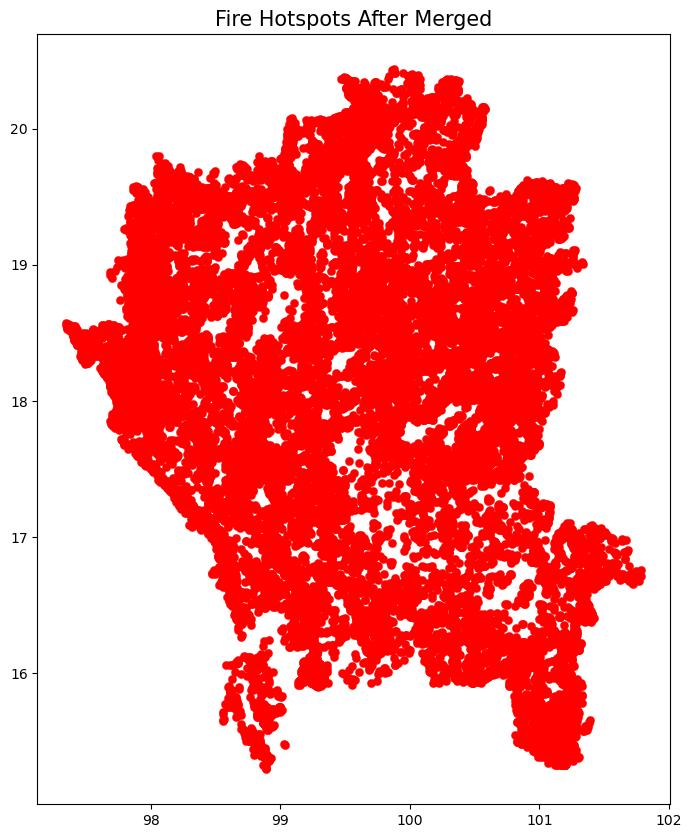

In [54]:
fig, ax = plt.subplots(figsize=(10, 10))
df_fire_final.plot(ax=ax, color='red', linewidth=0.2)

ax.set_title("Fire Hotspots After Merged", fontsize=15)
plt.show()

# Non-fire data

In [13]:
# Import necessary libraries for numerical operations, data manipulation, and geospatial data processing.
import numpy as np
import pandas as pd
from shapely.geometry import Point
import geopandas as gpd

# Assumption: You have a defined study area boundary (e.g., Bounding Box of Northern Thailand)
# Define the minimum and maximum longitude and latitude for spatial constraints.
min_lon, min_lat, max_lon, max_lat = 97.34, 15.17, 101.79, 20.46

# Set the desired number of non-fire points (e.g., equal to the number of fire points to balance the dataset)
n_non_fire = len(fire_df)

# Generate random coordinates
# Set a random seed for reproducibility, then generate random uniform longitudes and latitudes within the bounds.
np.random.seed(42)
lons = np.random.uniform(min_lon, max_lon, n_non_fire)
lats = np.random.uniform(min_lat, max_lat, n_non_fire)

# Randomly sample months and years (or use fully randomized dates)
# Define the pool of valid years and months, then randomly select values for each generated point.
years_pool = [2023, 2024, 2025]
months_pool = range(1, 13)

random_years = np.random.choice(years_pool, n_non_fire)
random_months = np.random.choice(months_pool, n_non_fire)

# Create random dates (approximated as the 1st of each generated month)
random_dates = [pd.to_datetime(f"{y}-{m:02d}-01") for y, m in zip(random_years, random_months)]

# Create a DataFrame
# Assemble the generated coordinates, dates, and the target label into a dictionary, then convert it to a pandas DataFrame.
non_fire_data = {
    'LONGITUDE': lons,
    'LATITUDE': lats,
    'ACQ_DATE': random_dates,
    'fire': 0  # Assign as Non-fire (Target class 0)
}
non_fire_df = pd.DataFrame(non_fire_data)

In [14]:
# Initialize an empty list to store the processed non-fire subsets.
all_non_fire_data = []

# Use the same loop structure as used for extracting Fire data
# Iterate through each raster file found in the directory.
for raster_path in raster_files:
    # Open the raster file to read its metadata and data.
    with rasterio.open(raster_path) as src:
        raster_bounds = src.bounds
        # print(f"Processing: {raster_path}") # Uncomment to track processing progress
        
        # 2. Extract year and month from the filename (assuming the filename is ...fire_feature_2023_01.tif)
        # Parse the filename string to dynamically identify the year and month.
        name = raster_path.split("/")[-1]
        parts = name.replace(".tif","").split("_")
        year = int(parts[3])
        month = int(parts[4])

        # 3. Filter point data (non_fire_df) specifically for the matching year/month AND ensuring they "must be within the spatial bounds" of this Raster
        # Create a spatial and temporal subset of the non-fire DataFrame that aligns perfectly with the current raster image.
        subset = non_fire_df[
            (non_fire_df["ACQ_DATE"].dt.year == year) &
            (non_fire_df["ACQ_DATE"].dt.month == month) &
            (non_fire_df['LONGITUDE'] >= raster_bounds.left) &
            (non_fire_df['LONGITUDE'] <= raster_bounds.right) &
            (non_fire_df['LATITUDE'] >= raster_bounds.bottom) &
            (non_fire_df['LATITUDE'] <= raster_bounds.top)
        ].copy()

        # Proceed only if there are points matching the spatial and temporal criteria.
        if len(subset) > 0:
            all_non_fire_data.append(subset) 
            
        # 4. Extract values (Sampling) from the Raster
        # Generate a list of coordinate tuples and extract the corresponding pixel values across all bands.
        coords = [(x, y) for x, y in zip(subset.LONGITUDE, subset.LATITUDE)]
        samples = np.array(list(src.sample(coords)))

        # 5. Store values into columns
        # Iteratively assign the extracted array data to new feature columns in our subset DataFrame.
        for i, name_feat in enumerate(feature_names):
            subset[name_feat] = samples[:, i]

        # (Note: In your original code, it appends to `all_fire_data` here. You might want to append to `all_non_fire_data` after the feature extraction is complete instead.)
        all_fire_data.append(subset)

# Combine all individual monthly/spatial non-fire subsets into one master DataFrame.
df_non_fire_merged = pd.concat(all_non_fire_data, ignore_index=True)

# Clean the dataset by dropping rows where the sampling resulted in missing values (NaN).
df_non_fire_final = df_non_fire_merged.dropna(subset=feature_names)

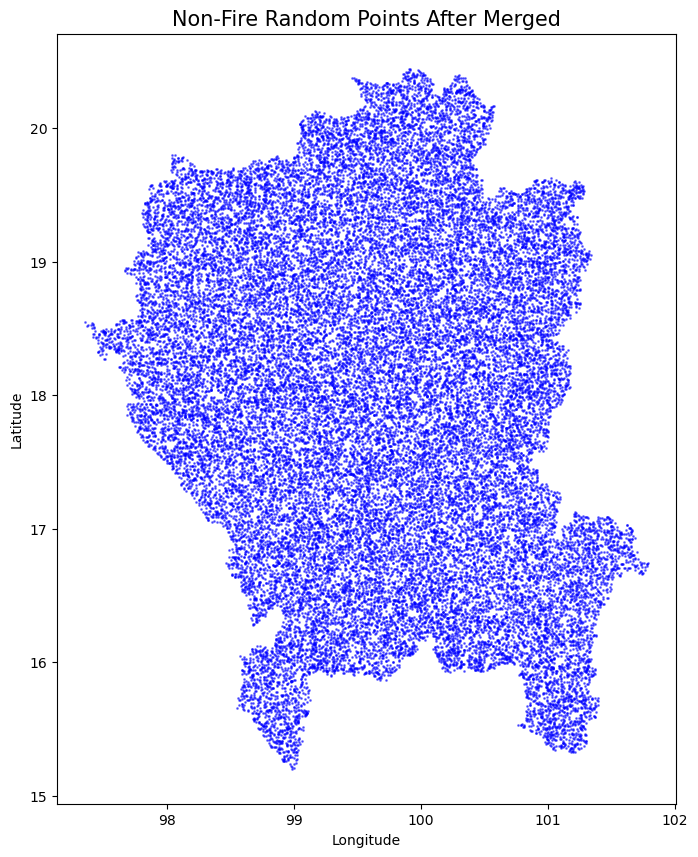

In [ ]:
gdf_non_fire_final = gpd.GeoDataFrame(
    df_non_fire_final, 
    geometry=gpd.points_from_xy(df_non_fire_final.LONGITUDE, df_non_fire_final.LATITUDE),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_non_fire_final.plot(ax=ax, color='blue', markersize=1, alpha=0.5)

ax.set_title("Non-Fire Random Points After Merged", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [15]:
df_non_fire_final.head()

,LONGITUDE,LATITUDE,ACQ_DATE,fire,ndvi,ndwi,nbr,blue,green,red,...,swir1,swir2,temp,soil_moisture,wind_u,wind_v,elev,slope,aspect,landcover
4,101.338566,16.699354,2023-01-01,0,0.467528,-0.411034,0.325225,1425.0,1660.0,1443.0,...,3017.0,2025.0,21.763477,0.191880,-0.977065,-0.751237,276.0,8.0,263.0,10.0
5,100.148567,17.667852,2023-01-01,0,0.221081,-0.263686,0.050684,1672.0,1836.0,2010.0,...,3324.0,2847.0,23.461777,0.214341,-0.556135,-0.468357,71.0,1.0,220.0,50.0
6,101.300524,19.049868,2023-01-01,0,0.480703,-0.434051,0.361070,1241.0,1446.0,1285.0,...,2558.0,1720.0,17.849918,0.288818,-0.443147,-0.045596,1027.0,12.0,277.0,10.0
8,100.277878,17.556326,2023-01-01,0,0.277352,-0.293276,0.044914,1584.0,1729.0,1790.0,...,3448.0,2892.0,22.971226,0.226130,-0.687185,-0.453407,93.0,1.0,341.0,10.0
10,99.071947,16.743671,2023-01-01,0,0.428040,-0.389415,0.269755,1258.5,1433.5,1306.5,...,2798.0,1876.0,21.773060,0.273015,-0.520762,0.553614,227.0,1.0,19.0,10.0


In [16]:
df_non_fire_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37809 entries, 4 to 67757
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   LONGITUDE      37809 non-null  float64       
 1   LATITUDE       37809 non-null  float64       
 2   ACQ_DATE       37809 non-null  datetime64[ns]
 3   fire           37809 non-null  int64         
 4   ndvi           37809 non-null  float32       
 5   ndwi           37809 non-null  float32       
 6   nbr            37809 non-null  float32       
 7   blue           37809 non-null  float32       
 8   green          37809 non-null  float32       
 9   red            37809 non-null  float32       
 10  nir            37809 non-null  float32       
 11  swir1          37809 non-null  float32       
 12  swir2          37809 non-null  float32       
 13  temp           37809 non-null  float32       
 14  soil_moisture  37809 non-null  float32       
 15  wind_u         37809 non

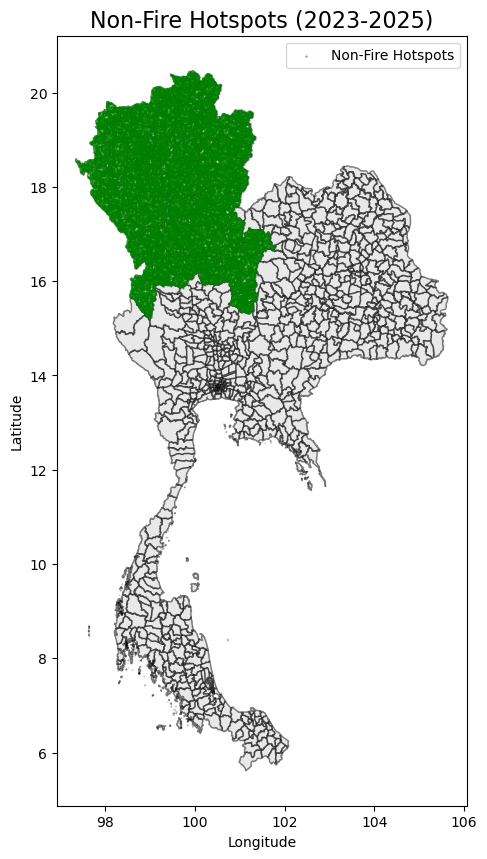

In [17]:
# Import necessary libraries for geospatial data manipulation and visualization.
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# 1. Convert df_non_fire_final to a GeoDataFrame
# Create a list of Shapely Point objects from the longitude and latitude coordinates.
geometry = [Point(xy) for xy in zip(df_non_fire_final['LONGITUDE'], df_non_fire_final['LATITUDE'])]
# Initialize a GeoDataFrame, assigning the geometry and setting the Coordinate Reference System (CRS) to standard WGS84 (EPSG:4326).
gdf_non_fire_final = gpd.GeoDataFrame(df_non_fire_final, geometry=geometry, crs="EPSG:4326")

# Initialize a plot figure and axes with a specific size of 10x10 inches.
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot the Thailand map as a background
# Load the shapefile of Thailand's boundaries and plot it as the base layer.
gdf_thailand = gpd.read_file("../../gadm41_THA_shp/gadm41_THA_2.shp")
gdf_thailand.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

# 3. Plot Non-Fire points (using the converted GeoDataFrame)
# Overlay the non-fire coordinate data onto the base map using green dots.
gdf_non_fire_final.plot(ax=ax, color='green', markersize=0.5, alpha=0.5, label='Non-Fire Hotspots')

# Add plot decorations
# Set the title, axis labels, and display the legend for clarity.
ax.set_title("Non-Fire Hotspots (2023-2025)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

# Render and display the final map visualization.
plt.show()

# Combine Dataset

In [18]:
df = pd.concat([df_fire_final, df_non_fire_final], ignore_index=True)

# Shuffle Data
df_final_model = df.sample(frac=1, random_state=42).reset_index(drop=True)

df["month"] = df["ACQ_DATE"].dt.month
df["year"] = df["ACQ_DATE"].dt.year

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

df_final_model.plot(ax=ax, color='blue', markersize=1, alpha=0.5)

ax.set_title("Fire + Non-Fire", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [19]:
print(df.head())
print(df.describe())
print(df["fire"].value_counts())

   LATITUDE  LONGITUDE  BRIGHTNESS  SCAN  TRACK   ACQ_DATE ACQ_TIME SATELLITE  \
0   15.3352   101.1958       316.7   1.0    1.0 2023-01-01     0644      Aqua   
1   15.9527   100.5264       323.3   1.1    1.0 2023-01-01     0644      Aqua   
2   15.9512   100.5164       326.5   1.1    1.0 2023-01-01     0644      Aqua   
3   16.1400   100.6051       319.9   1.1    1.0 2023-01-01     0644      Aqua   
4   16.1170   100.4562       315.4   1.1    1.0 2023-01-01     0644      Aqua   

  INSTRUMENT  CONFIDENCE  ...       temp  soil_moisture    wind_u    wind_v  \
0      MODIS        49.0  ...  23.827732       0.167730 -2.874125 -0.635948   
1      MODIS        77.0  ...  24.095718       0.132930 -1.286884 -0.055150   
2      MODIS        80.0  ...  24.095718       0.132930 -1.286884 -0.055150   
3      MODIS        74.0  ...  23.965410       0.131955 -1.273284 -0.151570   
4      MODIS        39.0  ...  24.084709       0.140155 -1.073631 -0.011908   

   elev slope  aspect  landcover  mont

# Visualization

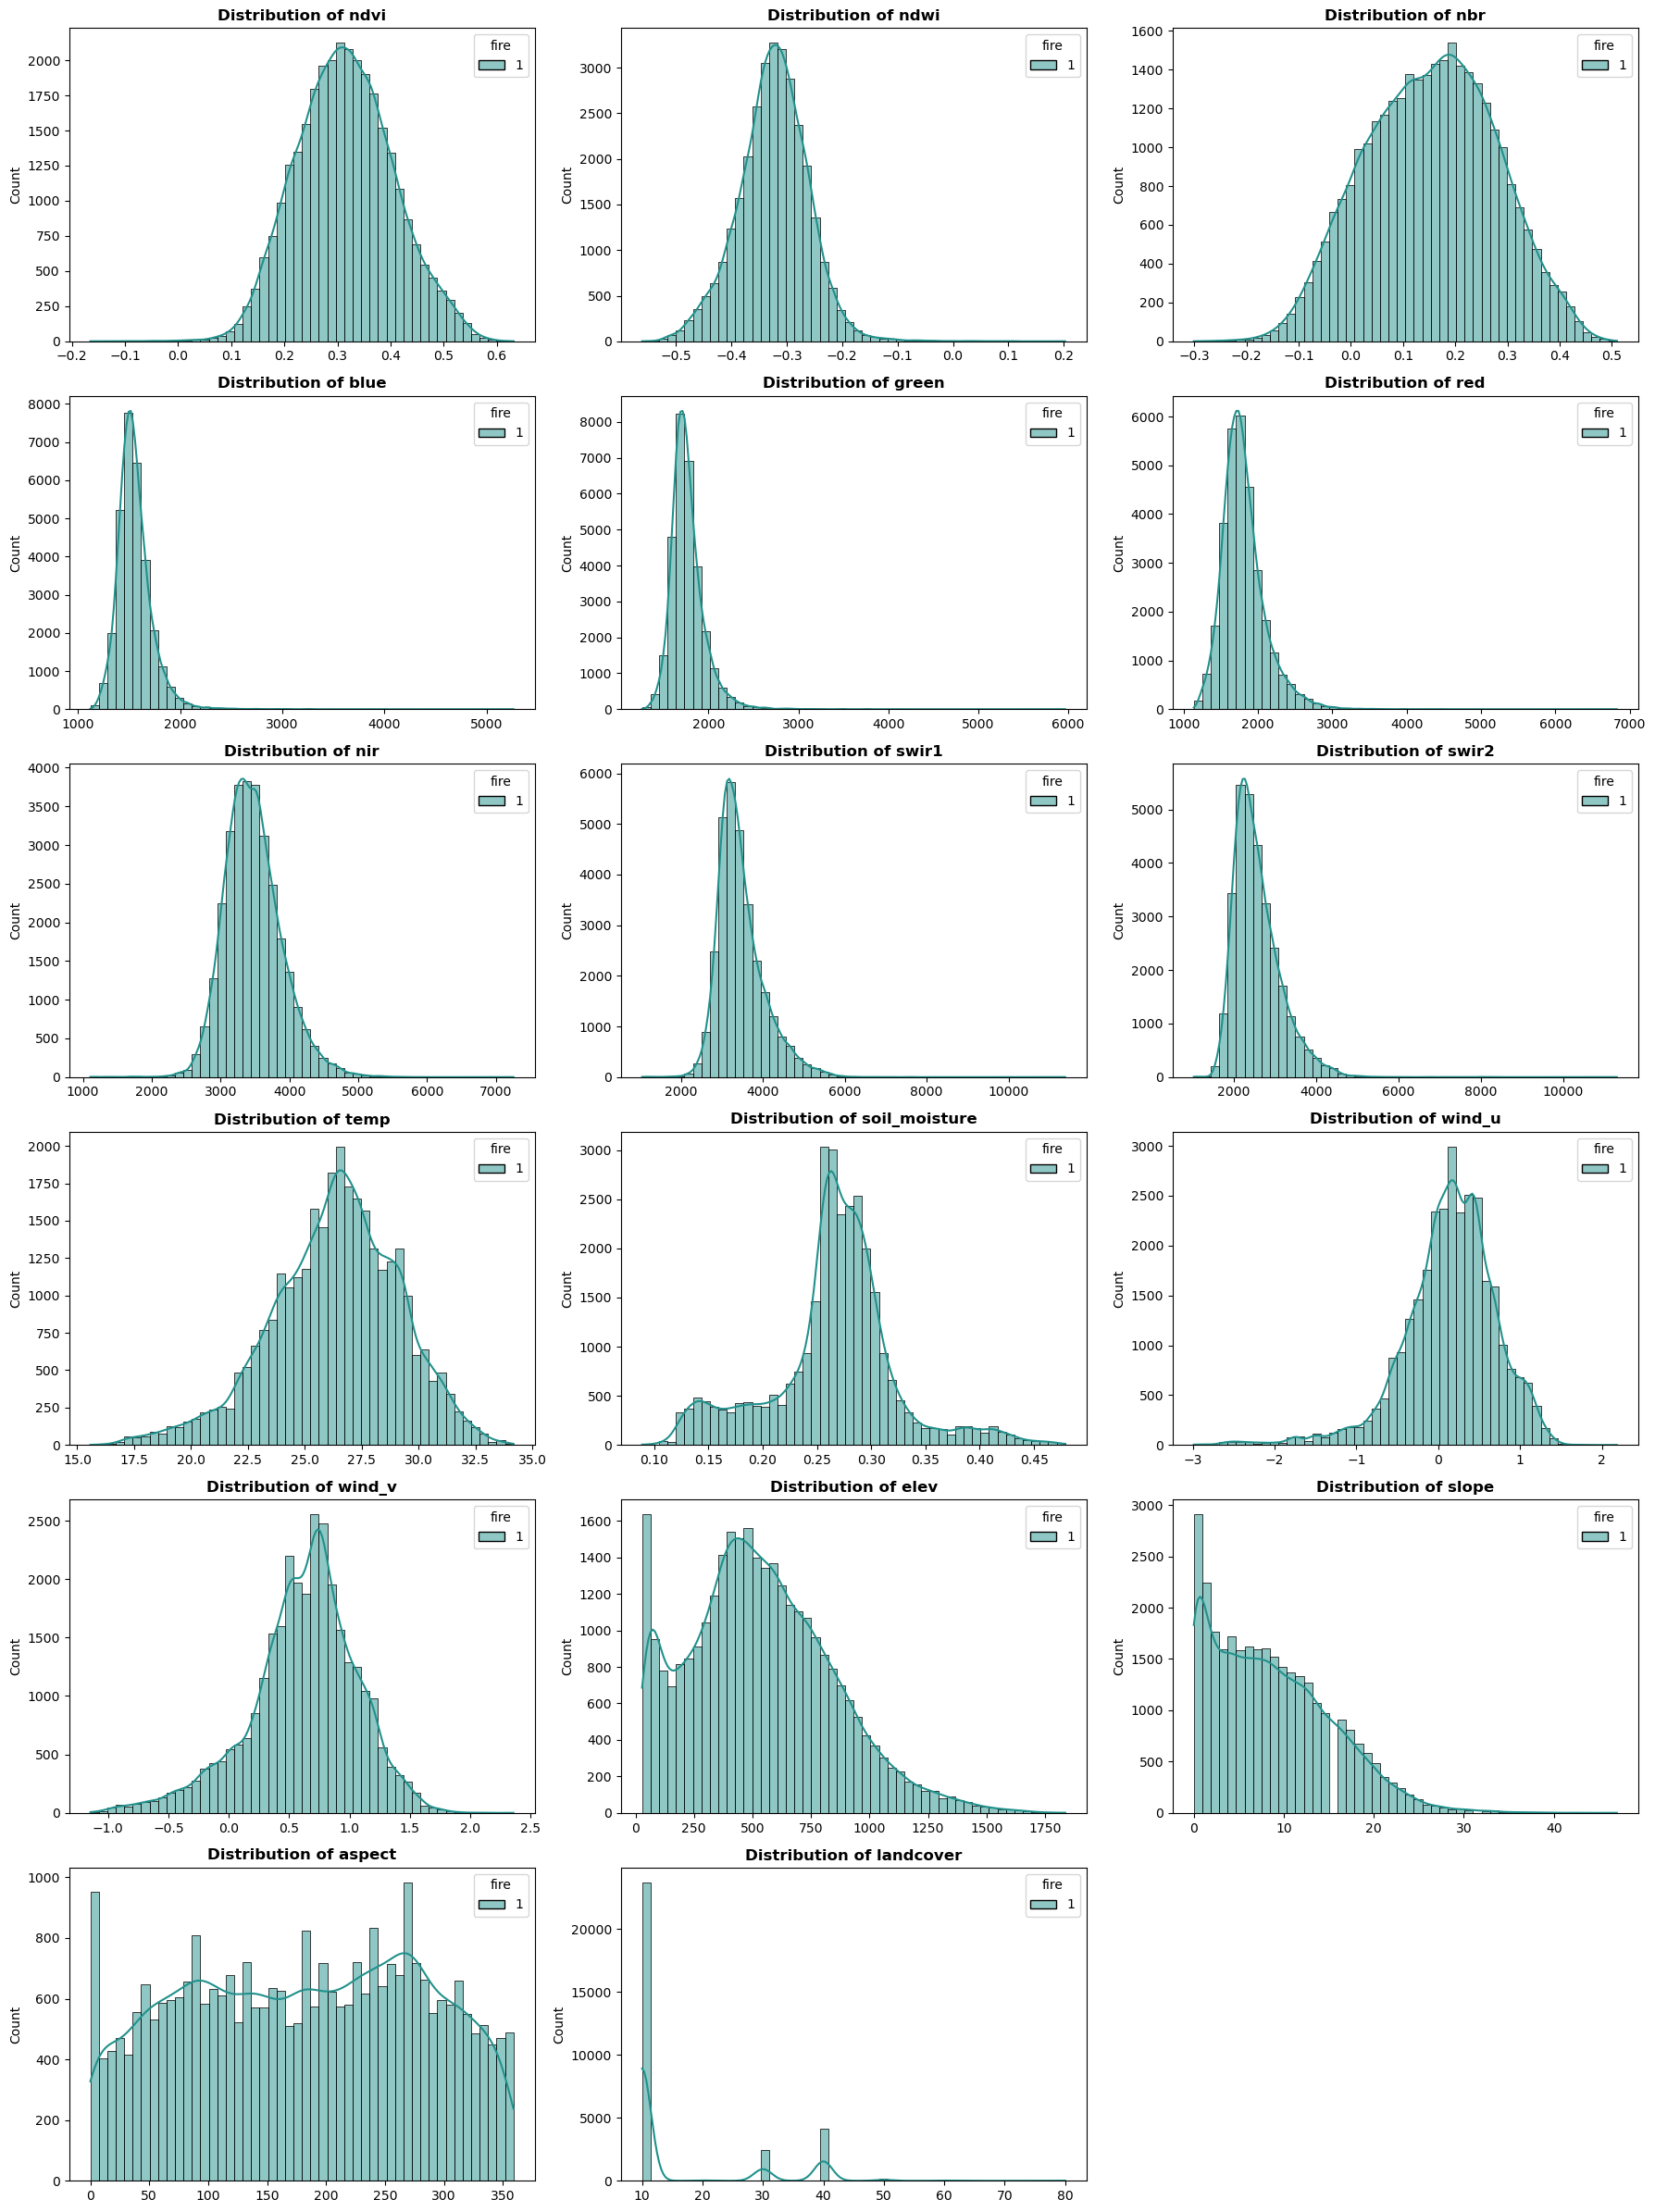

In [20]:
# Import seaborn and matplotlib for statistical data visualization and plotting.
import seaborn as sns
import matplotlib.pyplot as plt

# List of features to visualize based on your dataset
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

# Set the number of rows and columns for the Subplots grid
n_features = len(feature_names)
n_cols = 3
# Calculate the required number of rows dynamically based on the total number of features.
n_rows = (n_features + n_cols - 1) // n_cols

# Create the figure and subplots with a dynamic height based on the number of rows.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
# Flatten the axes array to 1D for easier iteration.
axes = axes.flatten()

for i, col in enumerate(feature_names):
    # Plot a histogram for each feature onto the corresponding subplot.
    # Use 'hue' to differentiate between Fire (1) and Non-fire (0) distributions.
    # 'kde=True' adds a Kernel Density Estimate line to show the data's shape.
    sns.histplot(data=df_fire_final, x=col, hue="fire", bins=50, kde=True, ax=axes[i], palette="viridis")
    
    # Set titles and formatting for each individual plot.
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("") # Remove x-axis label for a cleaner look as the title already specifies the feature.

# Remove any empty subplots if the number of features doesn't perfectly fill the grid.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Automatically adjust the padding between subplots to prevent overlapping text.
plt.tight_layout()
# Render and display the final compiled visualization.
plt.show()

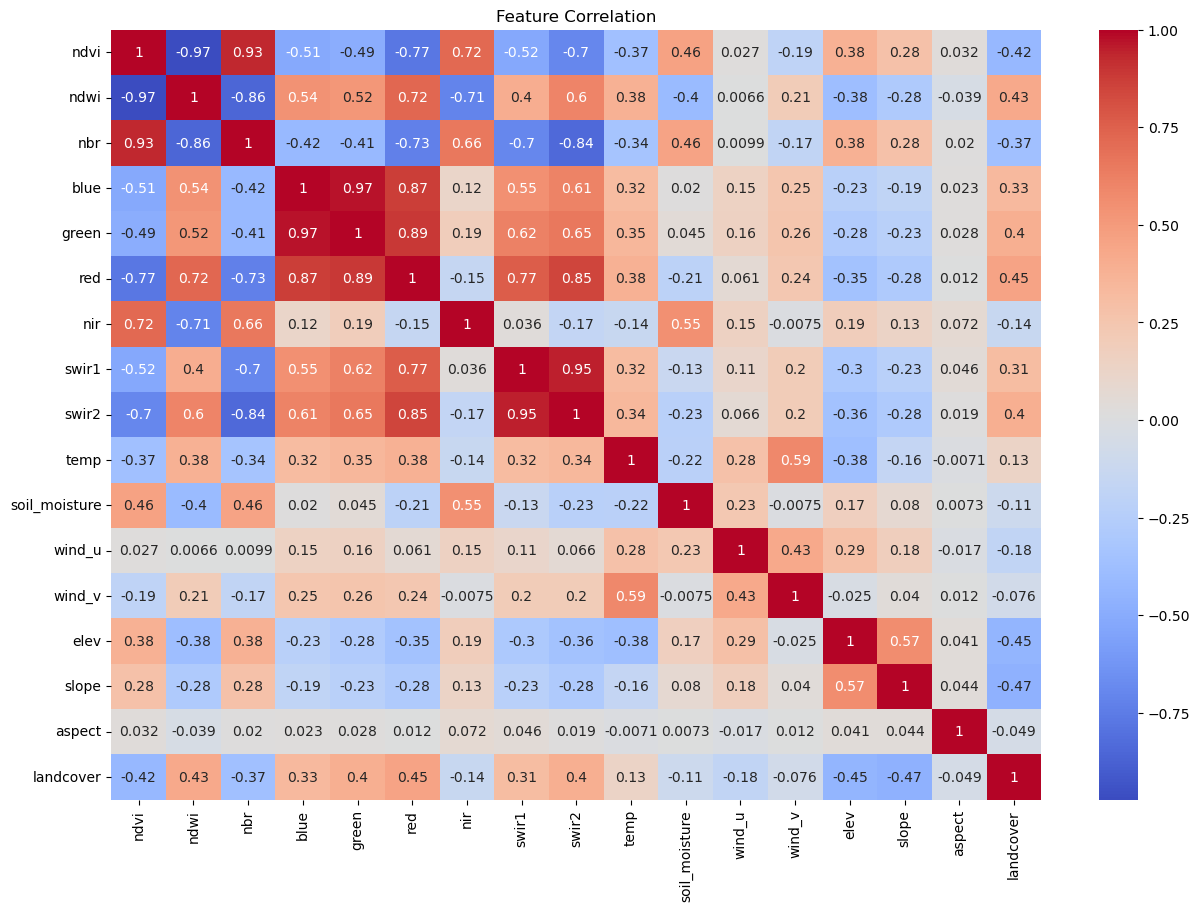

In [21]:
plt.figure(figsize=(15,10))
sns.heatmap(df[feature_names].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

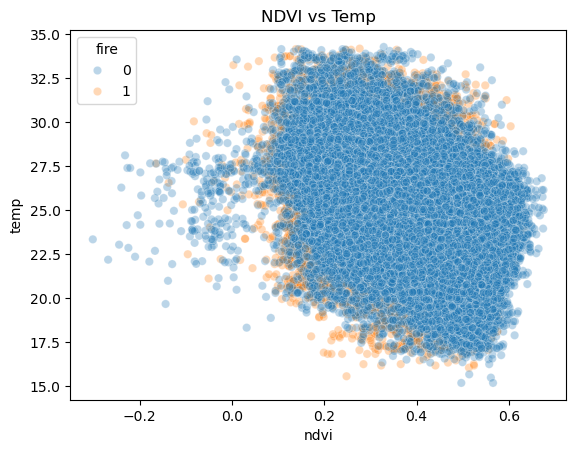

In [22]:
plt.figure()
sns.scatterplot(data=df, x="ndvi", y="temp", hue="fire", alpha=0.3)
plt.title("NDVI vs Temp")
plt.show()

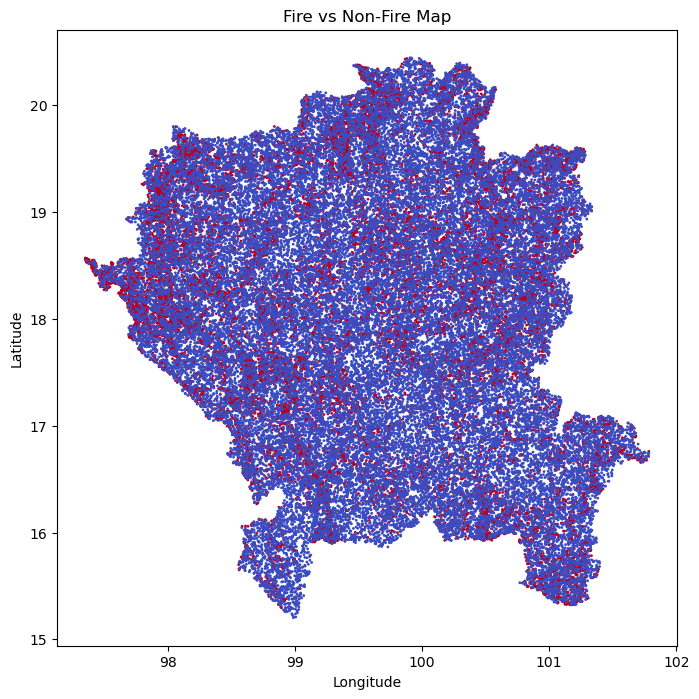

In [23]:
plt.figure(figsize=(8,8))

plt.scatter(df["LONGITUDE"], df["LATITUDE"],
            c=df["fire"], cmap="coolwarm", s=1)

plt.title("Fire vs Non-Fire Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

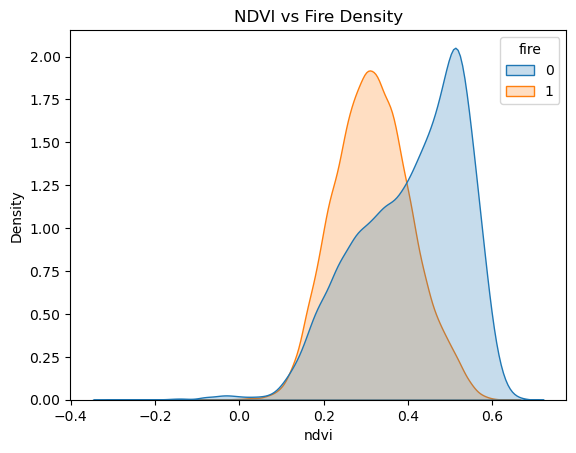

In [24]:
sns.kdeplot(data=df, x="ndvi", hue="fire", fill=True)
plt.title("NDVI vs Fire Density")
plt.show()

# Merge Districts

In [25]:
# Import geospatial libraries for handling geographic data and geometric shapes.
import geopandas as gpd
from shapely.geometry import Point

# 1. Convert the standard DataFrame into a GeoDataFrame
# Create a list of 'Point' objects using the Longitude and Latitude columns.
geometry = [Point(xy) for xy in zip(df.LONGITUDE, df.LATITUDE)]
# Initialize a GeoDataFrame with the data, geometry, and Coordinate Reference System (WGS84).
gdf_fire = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# 2. Load the Thai District-level Shapefile
# Read the administrative boundaries (level 2 refers to districts/Amphoe in GADM data).
gdf_amphur = gpd.read_file("../../gadm41_THA_shp/gadm41_THA_2.shp") 

# 3. Perform a Spatial Join to match points with geographic areas
# Use 'sjoin' to find which district polygon each point falls 'within'. 
# A 'left' join ensures we keep all original fire points even if they don't match a polygon.
gdf_joined = gpd.sjoin(gdf_fire, gdf_amphur, how="left", predicate="within")

# Now 'gdf_joined' will have new columns like Province ('NAME_1') and District ('NAME_2').
print(gdf_joined.head())

# Export the spatially enriched data to a CSV file for model training or analysis.
gdf_joined.to_csv("../Dataset/df_final_model.csv", index=False)

   LATITUDE  LONGITUDE  BRIGHTNESS  SCAN  TRACK   ACQ_DATE ACQ_TIME SATELLITE  \
0   15.3352   101.1958       316.7   1.0    1.0 2023-01-01     0644      Aqua   
1   15.9527   100.5264       323.3   1.1    1.0 2023-01-01     0644      Aqua   
2   15.9512   100.5164       326.5   1.1    1.0 2023-01-01     0644      Aqua   
3   16.1400   100.6051       319.9   1.1    1.0 2023-01-01     0644      Aqua   
4   16.1170   100.4562       315.4   1.1    1.0 2023-01-01     0644      Aqua   

  INSTRUMENT  CONFIDENCE  ...     GID_1      NAME_1            NL_NAME_1  \
0      MODIS        49.0  ...  THA.42_1  Phetchabun  อำเภอเมืองเพชรบูรณ์   
1      MODIS        77.0  ...  THA.44_1     Phichit        จังหวัดพิจิตร   
2      MODIS        80.0  ...  THA.44_1     Phichit        จังหวัดพิจิตร   
3      MODIS        74.0  ...  THA.44_1     Phichit        จังหวัดพิจิตร   
4      MODIS        39.0  ...  THA.44_1     Phichit        จังหวัดพิจิตร   

            NAME_2  VARNAME_2         NL_NAME_2       TY

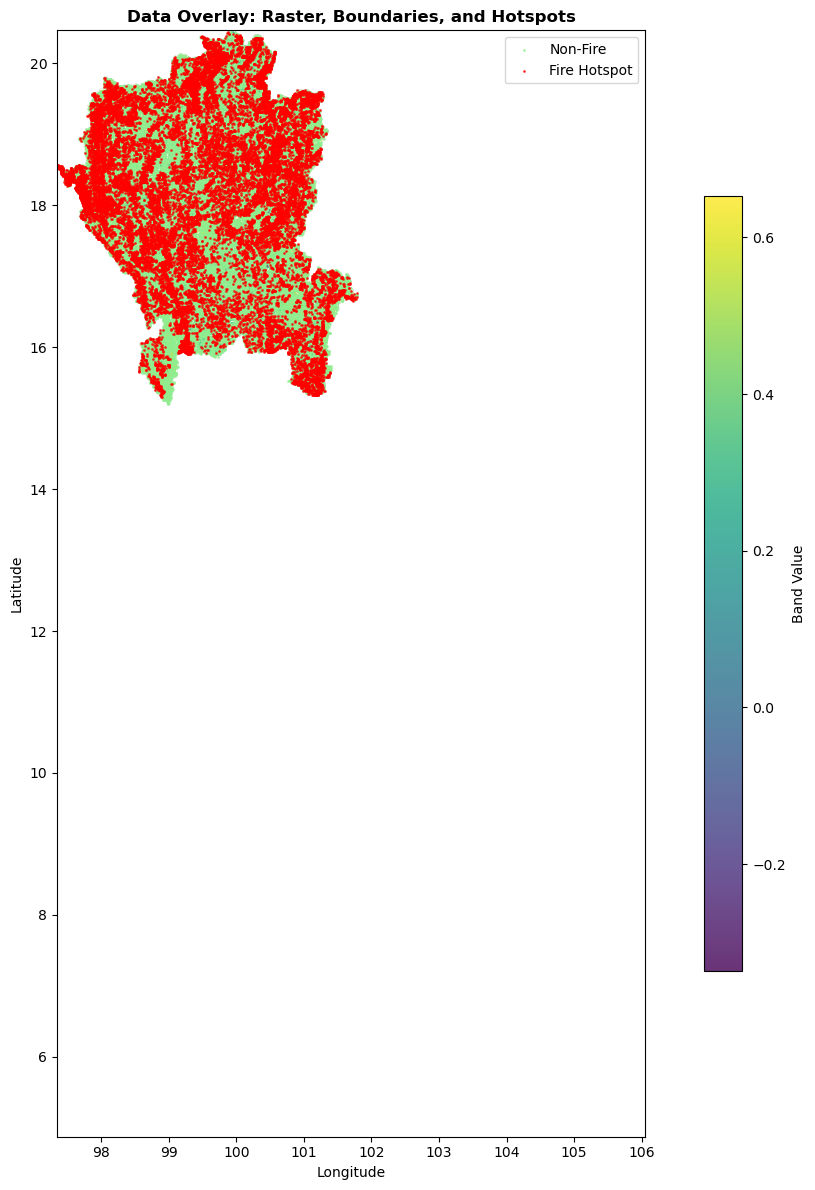

In [26]:
# Import geospatial libraries for vector and raster data handling and visualization.
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# 1. Define file paths
# Specify the path for the Raster file to be used as the background.
raster_path = "../../data/GEE_FIRE/fire_feature_2023_01.tif"

# 2. Create a figure with a size of 12x12 inches
fig, ax = plt.subplots(figsize=(12, 12))

# 3. Plot the background Raster (Assuming Band 1 - NDVI)
# Open the raster file using a context manager.
with rasterio.open(raster_path) as src:
    # Render the Raster image onto the 'ax' object.
    # 'transform' ensures the raster coordinates align with geographic space.
    # Set alpha to 0.8 to brighten the background so it doesn't obscure the overlay points.
    im = show(src.read(1), transform=src.transform, ax=ax, cmap='viridis', alpha=0.8, title='Data Overlay: Raster, Boundaries, and Hotspots')

    # (Optional) Add a color bar to represent the scale of the band values.
    fig.colorbar(im.get_images()[0], ax=ax, shrink=0.7, label='Band Value')

# 4. Overlay the District Boundaries Shapefile (gdf_amphur)
# *Crucial*: Set facecolor to 'none' to keep the polygons transparent, revealing the Raster below.
# Use a contrasting edgecolor like 'white' to make administrative boundaries visible.
gdf_amphur.plot(ax=ax, facecolor='none', edgecolor='white', linewidth=0.5)

# 5. Overlay Data Points (Fire & Non-Fire) from gdf_joined on top
# Filter and plot by category to distinguish between Fire and Non-Fire classes using colors.

# Points where no wildfire occurred (Non-Fire = 0) -> Light Green
gdf_joined[gdf_joined['fire'] == 0].plot(ax=ax, color='lightgreen', markersize=1, label='Non-Fire', alpha=0.7)

# Points where a wildfire occurred (Fire = 1) -> Red
gdf_joined[gdf_joined['fire'] == 1].plot(ax=ax, color='red', markersize=1, label='Fire Hotspot', alpha=0.7)

# 6. Configure axis labels and display the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Position the legend to clarify the symbols used on the map.
ax.legend(loc='upper right')

# Adjust layout to ensure elements are not cut off.
plt.tight_layout()
plt.show()

## Comparing 2 Factors by Fire Status

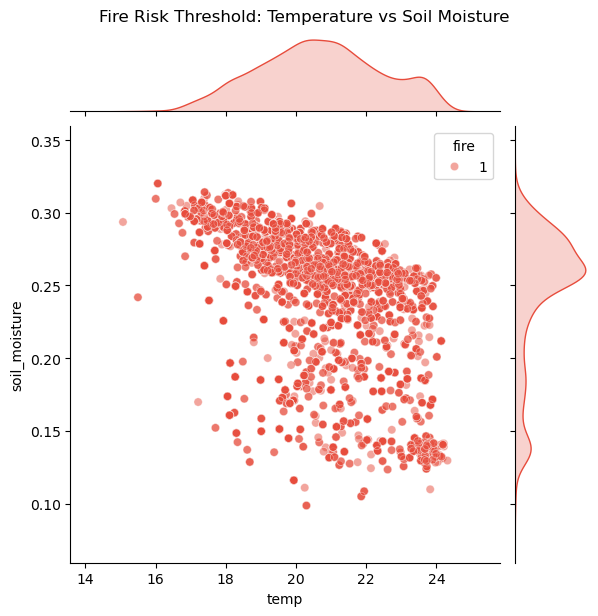

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use Jointplot to visualize both the Scatter plot and the Histogram for each axis
g = sns.jointplot(
    data=df_final.sample(5000), 
    x='temp', 
    y='soil_moisture', 
    hue='fire', 
    alpha=0.5,
    palette={0: "#3498db", 1: "#e74c3c"}
)

# Add a title to display the threshold or boundaries for better clarity
g.fig.suptitle('Fire Risk Threshold: Temperature vs Soil Moisture', y=1.02)
plt.show()

In [ ]:
import folium

# 1. Prepare district-level data (NAME_2)
# Sum the 'fire' occurrences for each unique combination of Province (NAME_1) and District (NAME_2)[cite: 1]
district_stats = gdf_joined.groupby(['NAME_1', 'NAME_2'])['fire'].sum().reset_index()

# 2. Load district boundaries (GADM Level 2)
# Read the shapefile containing administrative boundaries for Thai districts[cite: 1]
districts_geo = gpd.read_file('../../gadm41_THA_shp/gadm41_THA_2.shp')
# Filter the geographic data to include only the northern provinces[cite: 1]
districts_geo = districts_geo[districts_geo['NAME_1'].isin(north_provinces)]

# 3. Merge data
# Combine the fire statistics with the geographic boundaries based on province and district names[cite: 1]
district_map_data = districts_geo.merge(district_stats, on=['NAME_1', 'NAME_2'], how='left')
# Fill missing fire values with 0 for districts where no fire hotspots were found[cite: 1]
district_map_data['fire'] = district_map_data['fire'].fillna(0)

# 4. Create Folium map
# Initialize a base map centered on Northern Thailand coordinates with a clean background style[cite: 1]
m = folium.Map(location=[18.5, 99.0], zoom_start=7, tiles='CartoDB positron')

# 5. Add Choropleth data layer
# Create a color-coded map layer where darker colors represent higher fire counts[cite: 1]
folium.Choropleth(
    geo_data=district_map_data,
    name='Choropleth',
    data=district_map_data,
    columns=['NAME_2', 'fire'],
    key_on='feature.properties.NAME_2',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Fires by District'
).add_to(m)

# 6. Add Tooltips to show district name and fire count on hover
# Define styling for normal and highlighted (hovered) states
style_function = lambda x: {'fillColor': '#ffffff00', 'color':'#000000', 'fillOpacity': 0.1, 'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.50, 'weight': 0.1}

NIL = folium.features.GeoJson(
    district_map_data,
    style_function=style_function, 
    control=False,
    highlight_function=highlight_function, 
    tooltip=folium.features.GeoJsonTooltip(
        fields=['NAME_1', 'NAME_2', 'fire'],
        aliases=['Province: ', 'District: ', 'Fires: '],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;") 
    )
)
m.add_child(NIL)
m.keep_in_front(NIL)

# Save as an HTML file
# Export the interactive map for viewing in a web browser[cite: 1]
m.save('district_risk_map.html')